# 2026年8月5日 2026機械学習PJ 第1回 機械学習の概要 説明ノートブック

本ノートブックでは，以下の内容を知る/触れることを目的とする:
1. 機械学習モデルはどのように構築されるのか
2. モデルに入れるデータはどのように扱われるのか
3. モデルの精度を大きく左右するパラメータを変更することによる影響をどのように検証/評価するのか
4. モデルの学習時にどのような工夫ができるのか
5. モデルの種類を変えることによりどういう変化があるか

取り組む皆さんに注意してほしいこと:
- ここでは平易な説明を目的としているため，学術書のような堅い言い回しではないことをご理解ください．
- 全てを完璧にしてほしいということではなく，ここでは**モデルはどのように構築されるのか**と**データはどう扱われるのか**を最重要なポイントとして意識しましょう．
    - 細かいコードの意味がわからないこともあるかも知れませんが，機械学習の実装では，競プロのようにゼロから組み立てるものではなく，scikit-learnやPyTorchなどに**組み込まれているものを呼び出して使う**場合が大変多いので，コードの意味がわからないからといってずっと置いていかれる必要はありません．
- 今回は概要で，第2回においてより詳細に「教師なし学習」や「深層学習」を説明するし，Kaggleプロジェクトにおいても最初はよりシンプルなものから取り組む形になるので安心してください．
- 理論的な事項には触れないので，興味があれば様々な書籍などで勉強してください．

作成者: 坪井 一馬

## 0. 【重要】 説明

実装がよくわからなくても，この部分は理解してほしいです．

### 0.1. 教師あり学習

教師あり学習とは，**入力と出力(正解)が組となったデータに基づいて，入力から出力を正しく予測できるようにモデルを学習すること**です．つまり，目的は「**未知の入力からそれに対応する出力をより正確に出せるようになること**」です．

具体的な手法としては「回帰」と「分類」があります．
- 「回帰」は，出力として連続値の予測を行います．
- 「分類」は，出力として離散値の予測を行うか，あるいは「回帰」によって予測された確率と定めた閾値に基づいて行います(今回のロジスティック回帰はこちらです)．

ここではirisデータセットと呼ばれるものを扱います．このデータセットでは，アヤメという花の「がく片」と「花弁」それぞれの長さ，幅の合計4つの数値と，そのアヤメの品種が "setosa", "versicolor", "virginica" のどれかがまとまっています．

つまり，ここでの教師あり学習で行うのは「アヤメのがく片，花弁それぞれの長さ，幅の合計4つの数値」から「その花が "setosa", "versicolor", "virginica" の3種類のどれに分類されるのか」を正しく予測できるようにすることです．このとき，予測の材料となる4つの数値を「特徴量」といい，分類の対象となる3種類を「クラス」や「ラベル」といいます．

| 種類 | 内容 |
|---|---|
| 入力 | がく片，花弁の長さと幅 |
| 正解ラベル | setosa / versicolor / virginica |
| 目的 | 4つの特徴量からアヤメの種類を分類する |

学習には様々な手法がありますが，ここではロジスティック回帰による方法と，深層学習による方法の2通りを取り上げます．以下の節において具体的な実装とともに説明します．

また，ここでは「半教師あり学習」や「自己教師あり学習」などの専門的事項は説明しませんが，興味のある人は調べてみてください．

### 0.2. データセットの3分割

手元にあるデータセットから適切にモデルを構築し評価するには，少なくとも以下の3種類が必要です:
- 訓練データ(train): **モデルを実際に訓練/学習し，モデルが正しい予測を出せるようにする**ために使われる．
    - ここでは取り上げませんが，実際のKaggleコンペなどでは，より適切に学習が行われるようにするため，**前処理を施す**場合もあります．
- 評価データ(val): **どういう設定にしているモデルが良いかを選定する**ための中間的な検証で使われる．
    - 簡易的なモデルでは設定されないこともあります．
- テストデータ(test): **一切モデルの構築に関与しない**もので，**モデルの未知データへの性能を確認する**ために使われる．
    - 学習の過程でモデルは訓練データに適合しますが，訓練データに適合しすぎて未知のデータに対して全く正しい予測を出せなくなることがあり，そういう望ましくない状況を「過学習」と言います．
    - テストデータによる評価がなければ，そのモデルが本当に未知の予測に対して使えるのか，過学習が起きていないかどうかがわかりません．
    - また，テストでの評価が恣意的なものになってしまうことが否定できないため，評価データとしてテストデータを用いるのも望ましくありません．

手元にある全データからこの3種類に分割するとき，train:val:testの比率は6:2:2や8:1:1などとします．ここでは6:2:2としています．

### 0.3. モデル構築から学習の流れ

今回は，以下の4段階を重視して解説していきます．この流れによって，手元にあるデータからモデルを構築・学習し，最終的にそのモデルを評価するところまでいけます．

#### (1) データの準備

用いるデータセットを準備します．上述の3分割を行います．

#### (2) モデルの準備

学習するためのモデルの型を用意します．場合によっては，Pythonのクラスを実装し，そこからインスタンスを作成することもあります．

#### (3) 学習

用意したモデルに対して，用意した訓練データを用いて学習します．

評価データは，モデルの学習時の設定(ハイパーパラメータといいます)や学習データ自体など，広い意味での「学習の条件」を変更した場合の精度への影響を調べたい場合に用います．このような制度の調査は，より高精度なモデルを得ようとする場合に大変重要なプロセスとなり，コンペ等で差がつきます．

#### (4) テスト・推論

最終的に選ばれたモデルに対して，テストデータを入力した時に，それに対して用意されている正解を出力できるかを検証します．広い意味での教師あり学習の場合は，この結果がモデルの「精度」にあたります．

### 使用するライブラリの読み込み

Pythonにおいて機械学習モデルを実装するにあたって，必要となる機能を導入します．

今回は，**scikit-learn**と呼ばれる非常に便利なライブラリと，深層学習向けに**PyTorch**を導入します．

In [21]:
# 数値計算、表形式データ、可視化
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook上で表を見やすく表示するために使用する
from IPython.display import display

# scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [22]:
# 結果を再現しやすくするために乱数を固定
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# GPUが使える場合はGPU，使えない場合はCPUを使用
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("使用するデバイス:", device)

使用するデバイス: cpu


## 1. データの準備

学習に用いるirisデータセットを取得します．また，そのデータの中身を確認します．

### 1.1. EDA

今回は問題にはなりませんが，データ内に「欠損」がある場合は除去したり，あるいは補間する必要があり，**こういう小さな処理でも最終的なモデルの精度に差がつくことがあります**(機械学習の面白いところ！)．また，学習データの特徴量の分布を確認することも有効です．このように，学習データの傾向を詳細に分析してモデルの設計に役立てようとすることを**探索的データ分析**(Exploratory Data Analysis; EDA)といって，コンペ等では非常に重要です．

今回も実際に簡易的なEDAを行ってみます．そして，練習として備え付けのGeminiを使用したコード生成も体験してみます．

#### (1) データセットの読み込みと最初の5行の確認

得られたデータは`dataframe`という表形式で出てきます．ここでは`dataframe`の詳細な取り扱いの説明はしませんが，とりあえず表形式のデータだなとわかっておいてください．

In [23]:
# Irisデータセットをpandasの形式で読み込む
iris = load_iris(as_frame=True)

# 元の表をコピー
df = iris.frame.copy()

# 数字のラベルを、植物名へ対応付けた列も追加
target_name_map = dict(enumerate(iris.target_names))
df["species"] = df["target"].map(target_name_map)

print("データ数:", len(df))
print("特徴量:", list(iris.feature_names))
print("分類する種類:", list(iris.target_names))

# .head()で最初の5行を表示します．括弧内に数字を入れると，その行数分だけ表示されます．
display(df.head())

データ数: 150
特徴量: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
分類する種類: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


#### (2) データの形状，欠損値，クラス数を確認する

もしも欠損値があれば，その欠損がある行を削除するか，あるいは欠損を何らかの方法で補間する必要があります．

In [24]:
print("表の形:", df.shape)

print("\n列ごとの欠損値数:")
display(df.isna().sum())

print("\n種類ごとのデータ数:")
display(df["species"].value_counts())

表の形: (150, 6)

列ごとの欠損値数:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
species,0



種類ごとのデータ数:


,count
species,
setosa,50
versicolor,50
virginica,50


#### (3) 花弁に関する特徴量を散布図で確認して考察する

ここでは，花弁の長さと花弁の幅を取り上げて，散布図を見ます．

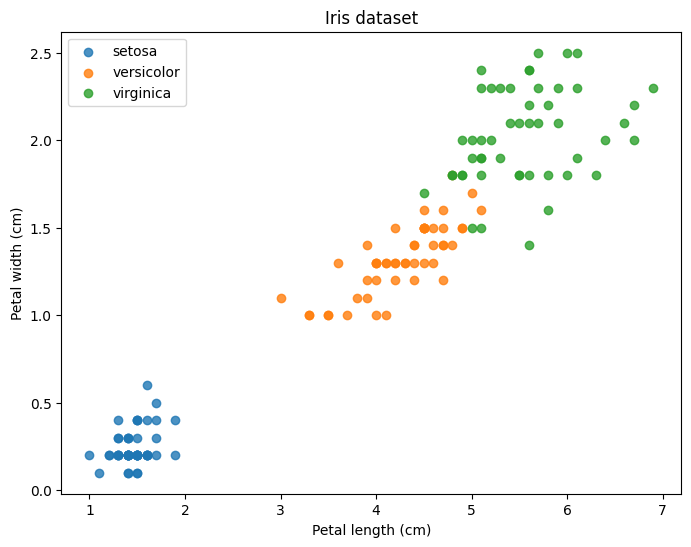

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

for target_id, species_name in enumerate(iris.target_names):
    subset = df[df["target"] == target_id]

    ax.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species_name,
        alpha=0.8,
    )

ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Iris dataset")
ax.legend()
plt.show()

**[問題1] 得られた散布図の考察**

ここで得られた散布図から，実際に4つの特徴量に基づいてアヤメの品種を分類する上で，どのようなことが予想できるかを考えよ．AIに頼らなくても，散布図を見ればすぐにわかると思います．

<回答はここに書き込む>

#### (4) がく片に関する特徴量を散布図で確認して考察する

**[問題2] Geminiを使用したコーディング**

上で花弁に関する特徴量の散布図はみましたが，みやすくするために2次元にしたので，がく片についてはわかっていません．そこで，Google ColaboratoryのGemini機能を使用し，がく片に対しても同様の散布図を生成させてみましょう．

In [26]:
# ここを選択して「右上のコードを生成する」からプロンプトを入れる．
# どういうプロンプトが良いかは自分で考えてみてください．

### 1.2. データの分割

それでは，訓練，評価，テストに分割します．

#### (1) 入力と出力との分割

便宜的に入力データ`X`と正解のラベル`y`に分割しておく必要があります．

In [27]:
# 4つの特徴量だけをX
X = df[iris.feature_names]

# 数字で表現された種類をy
y = df["target"]

# 念の為shapeを確認する
print("Xの形:", X.shape)
print("yの形:", y.shape)

Xの形: (150, 4)
yの形: (150,)


#### (2) 3分割

データの分割では，scikit-learnの`train_test_split`を使用しますが，1度に2つにしか分割できないので，次の2段階で3分割します。

```text
全データ
├─ 訓練データ 60%
└─ 一時データ 40%
      ├─ 評価データ 20%
      └─ テストデータ 20%
```

ここで，`stratify`を使うことで，3種類の割合が分割前後で大きく変わるのを防げます。余裕があれば，これを適用しない場合に精度がどうなるかも試してみてください．

実際の分析では，交差検証(k-fold CV)，複数の乱数による繰り返し評価，層化分割なども行われることがありますが，ここでは説明しません．

In [28]:
# 1回目の分割：
# 全体を訓練60%と一時データ40%へ分ける
(
    X_train,
    X_temp,
    y_train,
    y_temp,
) = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y,
)

# 2回目の分割：
# 一時データ40%を、評価20%とテスト20%へ分ける
(
    X_val,
    X_test,
    y_val,
    y_test,
) = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("訓練データ:", X_train.shape)
print("評価データ:", X_val.shape)
print("テストデータ:", X_test.shape)

訓練データ: (90, 4)
評価データ: (30, 4)
テストデータ: (30, 4)


## 2. ロジスティック回帰のモデルを準備

まずはロジスティック回帰に基づくモデルを実装します．ロジスティック回帰の数学的な背景は説明しませんが，何をしているかというと「**そのアヤメが分類されうる3種類について，それぞれに分類される確率**」を「回帰」によって予測します．

学習では「入力から正しい出力を得る」ことを目的としますが，ここでの「正しい出力」としては「正解のクラスに対応する確率を1，それ以外のクラスに対応する確率を0」としたものを考えるのが適切です．明示的にそのような実装はしませんが，内部ではそのように考えられています．そういうところも`model.fit`に含まれているので便利ですね．

以下では，次の2つを`Pipeline`というscikit-learnに備わった機能でまとめており，訓練データで学習した前処理を評価・テストデータへ同じ方法で自動的に適用することができます:
1. `StandardScaler`: 特徴量の大きさをそろえる
2. `LogisticRegression`: 分類する．引数として設定しているのは，学習時の設定でありモデルの性能を左右する**ハイパーパラメータ**です．ここでは一般的な値をあらかじめ入れてあります．

In [29]:
# モデルの定義
sklearn_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "classifier",
        LogisticRegression(
            C=1.0,
            max_iter=1000,
            solver="lbfgs",
        ),
    ),
])

print(sklearn_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000))])


## 3. 学習

### 3.1. 基本的な学習

`fit(X_train, y_train)`を呼び出すと，訓練データの特徴量と正解を受け取り，各クラスに対する確率を正しく予測する，つまり正しく分類するための「パラメータ」を学習します．

ここで「パラメータ」とは，**モデルの内部において，入力された特徴量から出力となる各クラスへの確率を計算するうえで重要となる係数**のことです．ここでの学習の目的は，適切な「パラメータ」の値を得て(学習して)，正解クラスに対する予測確率を高くしてそれ以外のクラスに対する予測確率を低くすることです．

例えば，3クラス分類で正解が setosa である場合，理想的には次のような予測を目指します．

| クラス | 予測確率 |
|---|---|
| setosa | 1.0 |
| versicolor | 0.0 |
| virginica | 0.0 |

実際には，学習の初期段階では

| クラス | 予測確率 |
|---|---|
| setosa | 0.55 |
| versicolor | 0.30 |
| virginica | 0.15 |

のような予測になることがあります．この予測結果と正解との差を数値として表したものが「損失」であり，その損失を計算する関数を「損失関数」と呼びます．学習では，この損失ができるだけ小さくなるようにモデルのパラメータを繰り返し更新します．損失が小さくなるほど，予測結果は正解に近づき、より正しく分類できるモデルになります．

scikit-learnでは，損失の計算やパラメータの更新といった処理はすべて`fit()`の内部で自動的に実行されるので，利用者が損失関数や更新式を自ら実装する必要はありません．

In [30]:
# 訓練データだけを使って学習します。
sklearn_model.fit(
    X_train,
    y_train,
)

# 学習後のパラメータは以下のように確認できます
print(hasattr(sklearn_model["scaler"], "mean_"))
print(hasattr(sklearn_model["classifier"], "coef_"))

True
True


## 3.2. 評価データによる確認

評価データは，モデルのハイパーパラメータや学習時に使用するデータに基づいて，**より良さそうなモデル**を選ぶために使います．真に良いかどうかは，一切モデルの学習や選定に関与しないテストデータで後で評価します．

ここでは，`C`を変更したときに評価精度がどう変わるかを確認してみようと思います．2つ上のセルで`C=1.0`を`C=100.0`にしてみましょう．

In [31]:
# 評価データを予測
sklearn_val_predictions = sklearn_model.predict(X_val)

# 正解率を計算
sklearn_val_accuracy = accuracy_score(
    y_val,
    sklearn_val_predictions,
)

print(f"評価データの正解率: {sklearn_val_accuracy:.3f}")

評価データの正解率: 0.933


今は手動で変更しましたが，最初から評価データによる確認を行うことを前提として実装することもできます．

以下のように`candidate_c_values`というリストを定義し，リスト内に候補を入れて，`for c_value in candidate_c_values:`の繰り返し以下で`c_value`の値を変更して学習，評価を行うことで，リストに入れた候補のうちでどれが良いのかを調べることができます．

In [32]:
candidate_c_values = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]

sklearn_tuning_results = []

for c_value in candidate_c_values:
    candidate_model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=c_value,
                max_iter=2000,
                solver="lbfgs",
            ),
        ),
    ])

    # 候補モデルは、すべて訓練データだけで学習
    candidate_model.fit(
        X_train,
        y_train,
    )

    train_predictions = candidate_model.predict(X_train)
    val_predictions = candidate_model.predict(X_val)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions,
    )

    val_accuracy = accuracy_score(
        y_val,
        val_predictions,
    )

    sklearn_tuning_results.append({
        "C": c_value,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
    })

sklearn_tuning_df = pd.DataFrame(
    sklearn_tuning_results
)

display(sklearn_tuning_df)

,C,train_accuracy,val_accuracy
0,0.01,0.888889,0.833333
1,0.10,0.922222,0.866667
2,1.00,0.977778,0.933333
3,10.00,0.988889,0.933333
4,100.00,1.000000,0.966667


結果として`c=100.00`が良いとわかりましたが，もっと多くの候補を探索した場合のことに備えて，結果の`dataframe`から評価精度が最大の行を選んで，その時の`c`の値を`best_c`として，最終的なテストデータへの検証に使うことにします．

In [33]:
# 評価精度が最大の行を選ぶ
best_sklearn_index = (
    sklearn_tuning_df["val_accuracy"].idxmax()
)

best_c = float(
    sklearn_tuning_df.loc[best_sklearn_index, "C"]
)

best_sklearn_val_accuracy = float(
    sklearn_tuning_df.loc[
        best_sklearn_index,
        "val_accuracy",
    ]
)

print("評価データで選ばれたC:", best_c)
print(
    f"そのときの評価精度: "
    f"{best_sklearn_val_accuracy:.3f}"
)

評価データで選ばれたC: 100.0
そのときの評価精度: 0.967


## 4. テスト・推論

実際にテストデータへの予測結果が出たあと，その結果が良くなければ(大体の場合は良くないんですが)，一切学習に使われていないデータに対してどうしてうまくいかないのかを分析することは重要です．

### 4.1. 再学習とテストデータへの予測

評価データに基づいて`C`が決まったので，訓練データに対して再度学習し，テストデータに対する予測をしてモデルの精度を確認しましょう．

In [34]:
# 評価データで選んだCを使って、最終モデルを作る
final_sklearn_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            C=best_c,
            max_iter=2000,
            solver="lbfgs",
        ),
    ),
])

# 訓練＋評価データで再学習
final_sklearn_model.fit(
    X_train,
    y_train,
)

# 最後にテストデータを予測
final_sklearn_predictions = (
    final_sklearn_model.predict(X_test)
)

final_sklearn_accuracy = accuracy_score(
    y_test,
    final_sklearn_predictions,
)

print(
    f"ロジスティック回帰のテスト精度: "
    f"{final_sklearn_accuracy:.3f}"
)

ロジスティック回帰のテスト精度: 0.900


### 4.2. 混同行列を確認

正解率だけではどの種類を間違えたか分かりませんが，混同行列では行が正解，列が予測を表すため，より詳細な**分類間違い**を可視化できます．

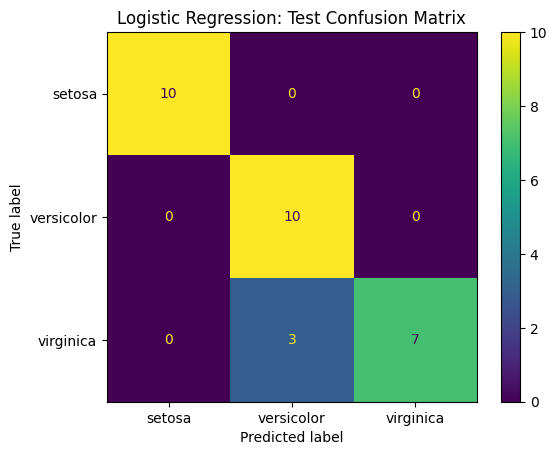

In [35]:
sklearn_cm = confusion_matrix(
    y_test,
    final_sklearn_predictions,
)

sklearn_display = ConfusionMatrixDisplay(
    confusion_matrix=sklearn_cm,
    display_labels=iris.target_names,
)

sklearn_display.plot()
plt.title("Logistic Regression: Test Confusion Matrix")
plt.show()

In [36]:
print(
    classification_report(
        y_test,
        final_sklearn_predictions,
        target_names=iris.target_names,
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



### 4.3.新しい1件を推論する

学習や評価が終わったモデルへ，新しい入力を与えて予測する処理を**推論**と呼びます．`predict_proba`を使うと、各クラスに対する予測確率も確認できます．

In [37]:
sample_index = 0

sample_X = X_test.iloc[[sample_index]]
sample_true_label = y_test.iloc[sample_index]

sample_prediction = final_sklearn_model.predict(
    sample_X
)[0]

sample_probabilities = (
    final_sklearn_model.predict_proba(sample_X)[0]
)

print(
    "正解:",
    iris.target_names[sample_true_label],
)

print(
    "予測:",
    iris.target_names[sample_prediction],
)

probability_df = pd.DataFrame({
    "species": iris.target_names,
    "probability": sample_probabilities,
})

display(probability_df)

正解: versicolor
予測: versicolor


,species,probability
0,setosa,0.000691
1,versicolor,0.999207
2,virginica,0.000102


## 5. 深層学習による分類モデルの構築

ロジスティック回帰に基づくモデルの学習は比較的簡易的な仕組みでしたが，人間の脳の情報処理の仕組みを模倣したニューラルネットワークを学習させる「深層学習」と呼ばれる手法があり，現在の主流となっています．深層学習の数学的な背景は複雑ですが，scikit-learnと同様にPyTorchと呼ばれるライブラリを使用して簡単に実行することができます．基本的な流れは，ロジスティック回帰における場合と同様です．

深層学習の詳細は第2回以降で説明しますが，ここでは同様にirisデータセットに対する分類モデルの学習を深層学習に基づいて行います．

なお，深層学習の実装のためのライブラリとしてKeras/Tensorflowが使われることもあり，微妙に実装が異なりますが，汎用性等の観点を考慮してPyTorchを扱います．

### 5.1. データの準備
PyTorchでは，データをテンソル(`Tensor`)として扱います．また，ニューラルネットワークは特徴量の大きさの影響を受けやすいため，訓練データだけを基準として標準化します．

In [38]:
# PyTorchのパラメータ選択段階では訓練データだけを基準として標準化
torch_scaler = StandardScaler()

X_train_scaled = torch_scaler.fit_transform(X_train)
X_val_scaled = torch_scaler.transform(X_val)
X_test_scaled = torch_scaler.transform(X_test)

# NumPy配列からPyTorch Tensorへ変換する
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.long,
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32,
)

y_val_tensor = torch.tensor(
    y_val.to_numpy(),
    dtype=torch.long,
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.long,
)

print("訓練用入力:", X_train_tensor.shape)
print("評価用入力:", X_val_tensor.shape)
print("テスト用入力:", X_test_tensor.shape)

訓練用入力: torch.Size([90, 4])
評価用入力: torch.Size([30, 4])
テスト用入力: torch.Size([30, 4])


深層学習では，一般に多くのデータが扱われることがあり，さらに学習の失敗を防ぐために，データを「ミニバッチ」と呼ばれる小さい単位に分割して学習を行います．特にPyTorchでは，データを`Dataset`と呼ばれるものにまとめて，それを`Dataloader`に流し込んで扱います．

- `TensorDataset`：入力と正解を1組にする
- `DataLoader`：データをミニバッチ単位で取り出す

In [39]:
# Dataset
train_dataset_torch = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

val_dataset_torch = TensorDataset(
    X_val_tensor,
    y_val_tensor,
)

test_dataset_torch = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

# Dataloader
train_loader_torch = DataLoader(
    train_dataset_torch,
    batch_size=16,
    shuffle=True,
)

val_loader_torch = DataLoader(
    val_dataset_torch,
    batch_size=32,
    shuffle=False,
)

test_loader_torch = DataLoader(
    test_dataset_torch,
    batch_size=32,
    shuffle=False,
)

print("訓練用バッチ数:", len(train_loader_torch))
print("評価用バッチ数:", len(val_loader_torch))
print("テスト用バッチ数:", len(test_loader_torch))

訓練用バッチ数: 6
評価用バッチ数: 1
テスト用バッチ数: 1


### 5.2. モデルの準備

深層学習で用いるモデルは，ニューラルネットワーク(ニューラルネット)と呼ばれます．「層」という情報の変換の単位を考えて，その「層」を多数重ねることにより，**単純に捉えられないような複雑な情報を捉える**ことを狙います．それぞれの「層」は一般に複数の「ユニット」で構成されています．ここでの「層」内でどのような変換が行われているかの数学的な詳細は説明しませんが，多くの深層学習の書籍で説明されています．

PyTorchでは，クラスとして`nn.Module`を継承して(元のクラスにある機能を部分的に上書きして)，モデルを定義します．クラス内のメソッドとして，以下の2つを用意します:
- `__init__`：使用する層を準備する
- `forward`：入力が層を通る順序を定義する

ここでのニューラルネットワークの構造は以下の通りです:

1. 入力層: 入力された4つの特徴量(がく片・花弁の長さと幅)を，4個のユニットで受け取ります．
2. 中間層1: 入力層の4個のユニットから得られた情報を16個のユニットとそれぞれに対応する数値へ変換します．ここで得られる16個の数値は，入力データの特徴をモデル内部で表現したもので**内部表現(潜在表現)**と呼ばれます．
3. 中間層2: 中間層1で得られた16個の内部表現をさらに8個のユニットへ変換する．この処理によって，分類に必要な特徴をより強調した内部表現へと変換します．
4. 出力層: 最後に，8個の内部表現を3個のユニットへ変換します．それぞれのユニットは，3種類のアヤメ(setosa, versicolor, virginica)に対応するスコアを出力し，ソフトマックス関数と呼ばれる活性化関数によって，各クラスである確率へ変換されます．そして，最も確率が高いクラスがモデルの予測結果となります．
    - ここで，ユニットから出力されるスコアそのものを「活性」や「ロジット」といいます．そのままでは0から1の範囲の確率として扱うことができないため，ソフトマックス関数などパラメータのなく値域が0以上1以下の関数に渡すことによって，確率値として得ます．

ニューラルネットの構造をどのように設定するかによってモデルの精度は大きく変わることがあります．層を深くする(中間層の数を増やす)ことでより複雑な情報を表現できるようになることが期待されるが，逆に層が深すぎると訓練データの細かい特徴までとらえすぎて，テストデータへの性能が悪くなることがあります．逆に層を浅くすると，単純な情報しか学習されなくなってしまうことがあります．

In [40]:
# モデルの設計図にあたるクラスを用意
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # 4個の特徴量を16個へ変換
            nn.Linear(4, 16),
            nn.ReLU(),

            # さらに8個の中間表現へ変換
            nn.Linear(16, 8),
            nn.ReLU(),

            # 3種類のスコアを出力
            nn.Linear(8, 3),
        )

    def forward(self, x):
        return self.network(x)

# 設計図から実体となるインスタンスを作り，deviceに送る
torch_model = IrisNet().to(device)

# モデルの構造が出力される
print(torch_model)

IrisNet(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


### 5.3. 学習

ここでの学習では，ロジスティック回帰の場合と同様に，予測と正解の違いを測る損失関数の用意と，それで計算された損失関数の値が小さくなるようにモデルの「パラメータ」を更新する最適化手法が重要になります．なお「パラメータ」は，ニューラルネットの各層を構成する「ユニット」同士の数値の変換を制御するものです．

ここでは，損失関数として多クラス分類のためのクロスエントロピー損失(`CrossEntropyLoss`)を使い，最適化のためのツールとして`Adam`と呼ばれるものを用います．

In [41]:
# 損失関数の定義
torch_loss_function = nn.CrossEntropyLoss()

# 損失関数に基づいてパラメータを最適化するための用意
torch_optimizer = torch.optim.Adam(
    torch_model.parameters(),
    lr=0.01,
)

実際の学習は関数としてまとめると，後で管理がしやすいです．損失関数を最小化するために，損失関数のパラメータによる偏微分を考えて，それを最小化できるようにしていきます．このような仕組みについては，厳密に説明しようとすると相当難しくはなってしまいますが，第2回においてもう少し具体的に説明しようと思います．

大まかな流れとして，**用意した「ミニバッチ」ごとに，学習データを通して損失関数を計算(順伝播)し，それを最小化できるようにモデルの内部のパラメータを修正する(逆伝播)ということ**がわかれば良いと思います．

In [42]:
def train_one_epoch(
    model,
    data_loader,
    loss_function,
    optimizer,
    device,
):
    # 学習モードへ切り替え
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for features, labels in data_loader:
        # モデルと同じCPUまたはGPUへ移動する
        features = features.to(device)
        labels = labels.to(device)

        # 前回の勾配をリセットする
        optimizer.zero_grad()

        # 予測を行う(順伝播)
        outputs = model(features)

        # 予測と正解から損失を計算
        loss = loss_function(
            outputs,
            labels,
        )

        # 逆伝播：修正方向を計算
        loss.backward()

        # パラメータを更新
        optimizer.step()

        total_loss += loss.item() * features.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

ここでも，ロジスティック回帰の場合と同様にモデルを評価データで評価します．評価時は以下の設定が重要です:
- `model.eval()`：評価モード
- `torch.no_grad()`：勾配計算を止める

In [43]:
def evaluate_torch_model(
    model,
    data_loader,
    loss_function,
    device,
):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)

            loss = loss_function(
                outputs,
                labels,
            )

            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * features.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    average_loss = total_loss / total
    accuracy = correct / total

    return (
        average_loss,
        accuracy,
        np.array(all_predictions),
        np.array(all_labels),
    )

評価データによる結果に基づいて，より最適な学習回数を探ります．エポック数とは，訓練データを何度繰り返して学習するかを表すものです．回数が少なすぎると学習が不十分で終わりますが，学習をしすぎると訓練データに過剰に適合します．

途中からの性能低下の可能性もあり，最後のエポックが最良とは限らないため，評価精度が最も高かった時点のモデルを保存します．

In [44]:
MAX_EPOCHS = 200

torch_train_loss_history = []
torch_train_accuracy_history = []
torch_val_loss_history = []
torch_val_accuracy_history = []

best_torch_val_accuracy = -1.0
best_torch_epoch = None
best_torch_state = None

for epoch in range(MAX_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        torch_model,
        train_loader_torch,
        torch_loss_function,
        torch_optimizer,
        device,
    )

    (
        val_loss,
        val_accuracy,
        _,
        _,
    ) = evaluate_torch_model(
        torch_model,
        val_loader_torch,
        torch_loss_function,
        device,
    )

    torch_train_loss_history.append(train_loss)
    torch_train_accuracy_history.append(train_accuracy)
    torch_val_loss_history.append(val_loss)
    torch_val_accuracy_history.append(val_accuracy)

    # 評価精度がこれまでで最も高ければ保存
    if val_accuracy > best_torch_val_accuracy:
        best_torch_val_accuracy = val_accuracy
        best_torch_epoch = epoch + 1
        best_torch_state = copy.deepcopy(
            torch_model.state_dict()
        )

    if (epoch + 1) % 40 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Acc: {train_accuracy:.3f} | "
            f"Val Acc: {val_accuracy:.3f}"
        )

print("評価データで選ばれたエポック:", best_torch_epoch)
print(
    f"最良の評価精度: "
    f"{best_torch_val_accuracy:.3f}"
)

Epoch  40 | Train Acc: 1.000 | Val Acc: 0.967
Epoch  80 | Train Acc: 1.000 | Val Acc: 0.967
Epoch 120 | Train Acc: 1.000 | Val Acc: 0.967
Epoch 160 | Train Acc: 1.000 | Val Acc: 0.967
Epoch 200 | Train Acc: 1.000 | Val Acc: 0.967
評価データで選ばれたエポック: 15
最良の評価精度: 0.967


エポックが増えることによる訓練データと評価データのそれぞれに対する性能の変化を示したものを学習曲線と言います．この学習曲線を同時に見ると，学習不足や過学習を考えやすくなります．

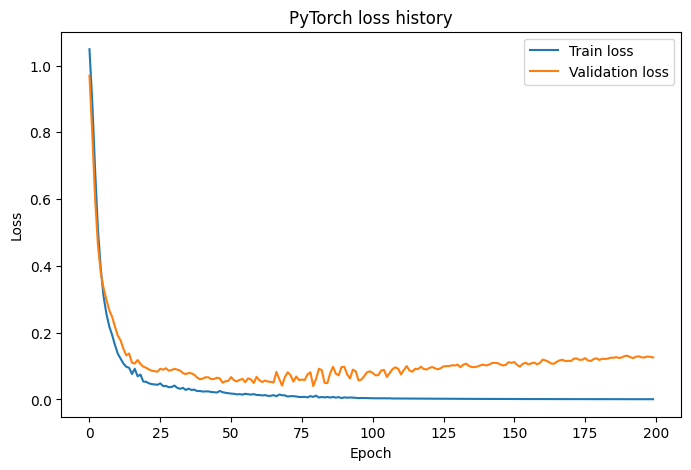

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    torch_train_loss_history,
    label="Train loss",
)

plt.plot(
    torch_val_loss_history,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch loss history")
plt.legend()
plt.show()

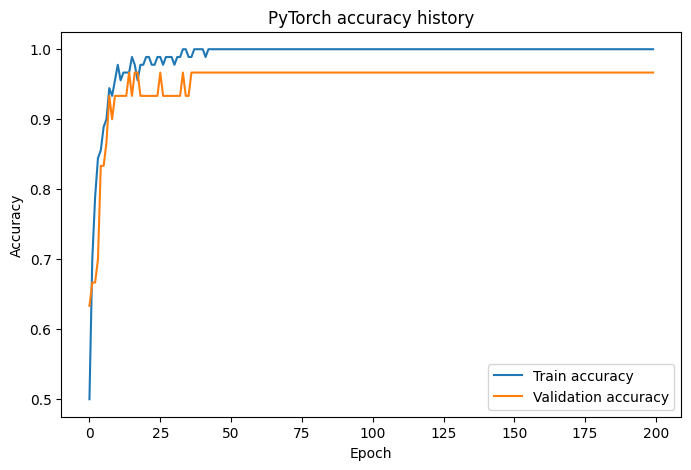

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    torch_train_accuracy_history,
    label="Train accuracy",
)

plt.plot(
    torch_val_accuracy_history,
    label="Validation accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch accuracy history")
plt.legend()
plt.show()

### 5.4. テスト・推論

評価データで選ばれた最良時点のモデルを復元し，テストデータを一度だけ評価します．

In [47]:
# 評価データで最良だったモデルを復元します。
torch_model.load_state_dict(
    best_torch_state
)

(
    torch_test_loss,
    torch_test_accuracy,
    torch_test_predictions,
    torch_test_true_labels,
) = evaluate_torch_model(
    torch_model,
    test_loader_torch,
    torch_loss_function,
    device,
)

print(
    f"PyTorchモデルのテスト精度: "
    f"{torch_test_accuracy:.3f}"
)

PyTorchモデルのテスト精度: 1.000


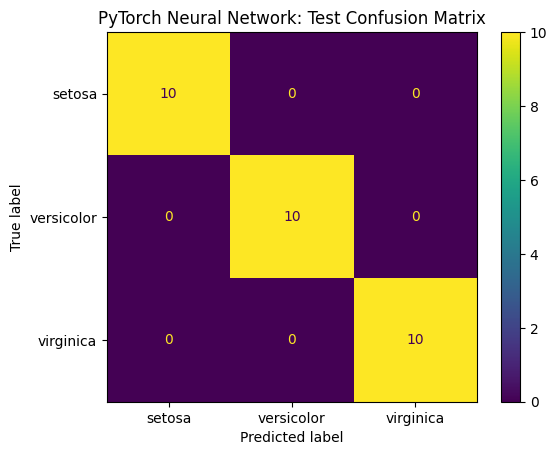

In [48]:
torch_cm = confusion_matrix(
    torch_test_true_labels,
    torch_test_predictions,
)

torch_display = ConfusionMatrixDisplay(
    confusion_matrix=torch_cm,
    display_labels=iris.target_names,
)

torch_display.plot()
plt.title("PyTorch Neural Network: Test Confusion Matrix")
plt.show()

新規の1件への推論として，ニューラルネットワークの最後の出力(活性，ロジット)はそのままでは確率ではありませんが，`softmax`を適用すると、3クラスの確率として読み取ることができます．

In [49]:
# テストデータからのサンプルデータの用意
torch_sample_index = 0

sample_tensor = X_test_tensor[
    torch_sample_index
].unsqueeze(0).to(device)

In [50]:
torch_model.eval()

with torch.no_grad():
    sample_output = torch_model(sample_tensor)

    sample_probability = torch.softmax(
        sample_output,
        dim=1,
    )

    sample_prediction = sample_probability.argmax(
        dim=1
    ).item()

print(
    "正解:",
    iris.target_names[
        y_test_tensor[torch_sample_index].item()
    ],
)

print(
    "予測:",
    iris.target_names[sample_prediction],
)

torch_probability_df = pd.DataFrame({
    "species": iris.target_names,
    "probability": (
        sample_probability
        .cpu()
        .numpy()[0]
    ),
})

display(torch_probability_df)

正解: versicolor
予測: versicolor


,species,probability
0,setosa,0.003177
1,versicolor,0.856621
2,virginica,0.140202


## 6. scikit-learnのロジスティック回帰とPyTorchの深層学習を比較する

両者を同じテストデータで比較します．

,model,test_accuracy
0,Logistic Regression,0.9
1,PyTorch Neural Network,1.0


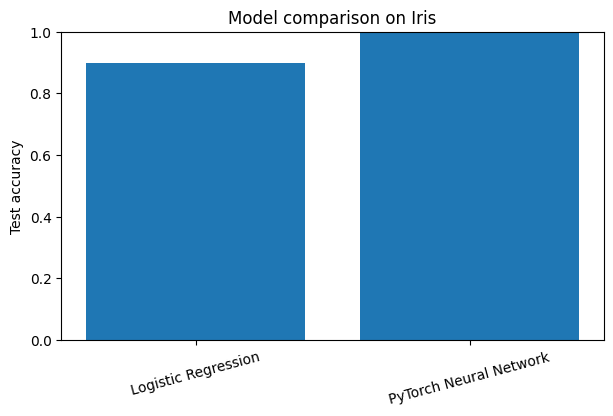

In [51]:
model_comparison_df = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "PyTorch Neural Network",
    ],
    "test_accuracy": [
        final_sklearn_accuracy,
        torch_test_accuracy,
    ],
})

display(model_comparison_df)

plt.figure(figsize=(7, 4))

plt.bar(
    model_comparison_df["model"],
    model_comparison_df["test_accuracy"],
)

plt.ylim(0.0, 1.0)
plt.ylabel("Test accuracy")
plt.title("Model comparison on Iris")
plt.xticks(rotation=15)
plt.show()

[**問題3**] モデルの比較

この性能の比較を見て，どのようなことが言えますか？また，深層学習に基づくモデルのほうがロジスティック回帰に基づくモデルより優れていると一般に言えますか？

<ここに書き込む>

## まとめ

| モデル構築の段階 | scikit-learn | PyTorch |
|---|---|---|
| ①データ準備 | DataFrame, 分割 | Tensor, Dataset, DataLoader |
| ②モデル構築 | Pipeline, LogisticRegression | `nn.Module` |
| ③学習 | `fit` | 学習ループ |
| 損失計算 | 内部処理 | `loss_function` |
| パラメータ更新 | 内部処理 | `backward`, `step` |
| 評価 | `predict`, 指標 | `eval`, `no_grad`, 指標 |
| 推論 | `predict`, `predict_proba` | `model(x)`, `softmax` |
| 最終テスト | テストデータで一度 | テストデータで一度 |

実装方法は違っても，考え方は同じです．
特にPyTorchでは
「Tensor → Dataset / DataLoader → モデルクラス → 損失計算 → 誤差逆伝播 → パラメータ更新」
という流れが重要で，この流れはより高度なモデルでも共通します．